### Commutator optimization with different reference states

In [115]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import networkx as nx
import sys
import pyscf
import scipy
import ffsim

from itertools import combinations

sys.path.insert(0, "..")

In [2]:
import optimize

In [311]:
def basis_similarity(U):
    """Shows how close a square orthogonal matrix U is to a permutation.
    Maximum value is 1, minimum value is something like 1 / sqrt(dim U)"""
    row_ind, col_ind = scipy.optimize.linear_sum_assignment(-abs(U)**2)
    return abs(U[row_ind, col_ind]**2).sum() / U.shape[0]

In [312]:
# 1.089
# path_to_fci = "../outputs/H4_linear/20260512_160540_x_opt.txt"
# path_to_hf = "../outputs/H4_linear/20260512_161402_x_opt.txt"

# 2.067
# path_to_fci = "../outputs/H4_linear/20260512_171031_x_opt.txt"
# path_to_hf = "../outputs/H4_linear/20260512_155500_x_opt.txt"

# 2.556
# path_to_hf = "../outputs/H4_linear/20260512_152549_x_opt.txt"
# path_to_fci = "../outputs/H4_linear/20260512_153557_x_opt.txt"

# 4.022
path_to_fci = "../outputs/H4_linear/20260512_162443_x_opt.txt"
path_to_hf = "../outputs/H4_linear/20260512_163100_x_opt.txt"

# 4.022 but abc =(1, 1, -2)
# path_to_fci = "../outputs/H4_linear/20260512_182538_x_opt.txt"
# path_to_hf = "../outputs/H4_linear/20260512_182942_x_opt.txt"

xs_fci_opt = np.loadtxt(path_to_fci, skiprows=1)
xs_hf_opt = np.loadtxt(path_to_hf, skiprows=1)

params_fci_opt = pd.read_csv(
    path_to_fci + "_results.txt",
delimiter=" ")

params_hf_opt = pd.read_csv(
    path_to_hf + "_results.txt",
delimiter=" ")

In [313]:
best_row_hf = np.argmin(params_hf_opt["C_hf"])
best_row_fci = np.argmin(params_fci_opt["C_fci"])

best_x_fci = xs_fci_opt[best_row_fci, :]
best_x_hf = xs_hf_opt[best_row_hf, :]

In [314]:
params_hf_opt.iloc[best_row_hf]

V_fci    0.038851
V_hf     0.193745
C_fci    0.000005
C_hf     0.000005
b        1.477429
c       -1.638872
Name: 17, dtype: float64

In [315]:
params_fci_opt.iloc[best_row_fci]

V_fci    4.166730e-02
V_hf     2.851852e-04
C_fci    8.376744e-07
C_hf     3.215578e-04
b        9.999514e-01
c       -1.999954e+00
Name: 2, dtype: float64

In [316]:
def x_to_U(x, norb):
    iu = np.triu_indices(norb, k=1)
    rotation_generator = np.zeros((norb, norb))
    rotation_generator[iu] = x
    rotation_generator -= rotation_generator.T
    return scipy.linalg.expm(rotation_generator)

In [317]:
U_fci = x_to_U(best_x_fci[:-2], 4)
U_hf = x_to_U(best_x_hf[:-2], 4)

basis_similarity(U_hf @ U_fci.T)

0.5000088377670922

In [318]:
U_fci

array([[-0.01036208,  0.01032343,  0.7070209 , -0.70704137],
       [ 0.70702852,  0.70703364,  0.01036607,  0.0103272 ],
       [-0.70703317,  0.7070291 , -0.01035908,  0.01032643],
       [-0.01036308, -0.0103302 ,  0.70704079,  0.70702137]])

In [319]:
U_hf

array([[ 0.50722179,  0.49270574, -0.49267301,  0.50718874],
       [ 0.49266774, -0.50719163,  0.5072189 ,  0.492711  ],
       [ 0.49267279,  0.50718876,  0.50722875, -0.49269878],
       [ 0.50722586, -0.49270405, -0.49266752, -0.50719164]])

In [320]:
for w in range(params_fci_opt.shape[0]):

    some_x_fci = xs_fci_opt[w, :]
    U_fci = x_to_U(some_x_fci[:-2], 4)
    
    some_x_hf = xs_hf_opt[w, :]
    U_hf = x_to_U(some_x_hf[:-2], 4)

    print(basis_similarity(U_hf @ U_fci.T))
    
    # overlaps = U_fci.T @ U_hf
    # row_ind, col_ind = scipy.optimize.linear_sum_assignment(-abs(overlaps))
    # print(abs(overlaps[row_ind, col_ind]).sum())

0.99999989260285
0.5626205192703458
0.5004627178170638
0.7512897867339863
0.7500002668012398
0.9999964711483281
0.9999966790037005
0.7512613604953459
0.9999966832206205
0.5010038619910082
0.7500104340833412
0.5626452780438558
0.9999982461261167
0.9999965790973605
0.9999999806945966
0.9999982917473289
0.5025401770052196
0.9999999821677443
0.9999999640653828
0.999999963768038


In [321]:
Us_hf = [x_to_U(xs_hf_opt[i, :-2], 4) for i in range(xs_hf_opt.shape[0])]
Us_fci = [x_to_U(xs_fci_opt[i, :-2], 4) for i in range(xs_fci_opt.shape[0])]

In [322]:
hf_similarity_scores = np.zeros((len(Us_hf), len(Us_hf)))
for i, U_i in enumerate(Us_hf):
    for j, U_j in enumerate(Us_hf):
      hf_similarity_scores[i, j] = basis_similarity(U_i @ U_j.T)  

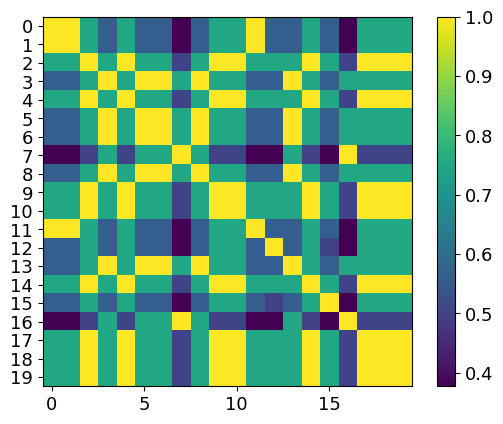

In [323]:
plt.imshow(hf_similarity_scores)
plt.colorbar()
plt.yticks(range(20))
plt.show()

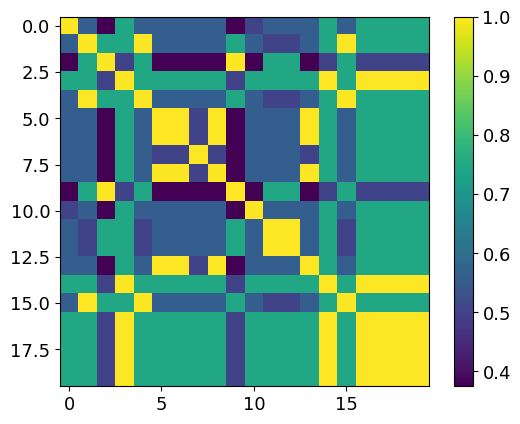

In [324]:
fci_similarity_scores = np.zeros((len(Us_fci), len(Us_fci)))
for i, U_i in enumerate(Us_fci):
    for j, U_j in enumerate(Us_fci):
      fci_similarity_scores[i, j] = basis_similarity(U_i @ U_j.T)  

plt.imshow(fci_similarity_scores)
plt.colorbar()

In [325]:
import networkx as nx

In [326]:
adj_hf = np.isclose(hf_similarity_scores, 1, atol=1e-2)

In [327]:
G_hf = nx.from_numpy_array(adj_hf)

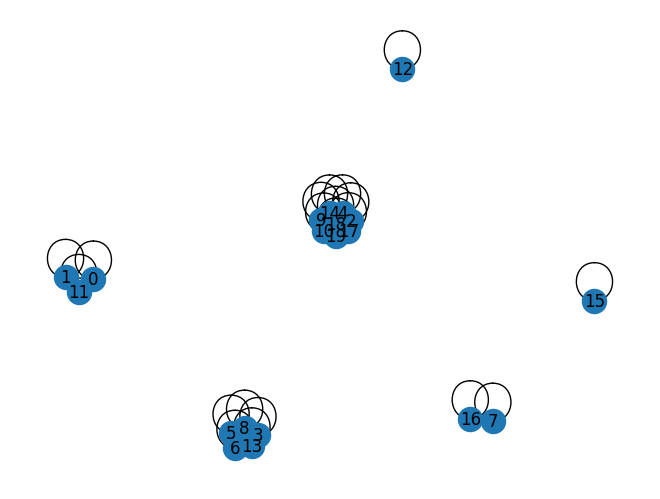

In [328]:
nx.draw(G_hf, with_labels=True)

In [329]:
Us_hf[0]

array([[ 4.92379243e-01, -5.07207011e-01,  5.07519717e-01,
         4.92673793e-01],
       [-7.17729336e-01, -6.59484364e-06,  6.96322195e-01,
        -1.12875022e-05],
       [ 1.06682357e-05, -6.96753817e-01, -7.23044416e-06,
        -7.17310336e-01],
       [-4.92369050e-01, -5.07222995e-01, -5.07502845e-01,
         4.92684904e-01]])

In [330]:
Us_hf[1]

array([[ 4.92356304e-01, -5.07230212e-01,  5.07513738e-01,
         4.92678991e-01],
       [ 7.66164734e-06,  6.96753816e-01,  1.39515478e-05,
         7.17310337e-01],
       [-7.17742969e-01, -2.25403325e-06,  6.96308143e-01,
        -3.68735318e-06],
       [-4.92372116e-01, -5.07199795e-01, -5.07528103e-01,
         4.92679705e-01]])

In [331]:
Us_hf[4]

array([[-0.50721677,  0.49270607,  0.49270058,  0.50716665],
       [-0.50719046, -0.49272094,  0.49268156, -0.507197  ],
       [ 0.49269971,  0.50717844,  0.50720498, -0.49270695],
       [ 0.49268243, -0.50718521,  0.50720225,  0.49272006]])

In [332]:
basis_similarity((Us_hf[4] @ Us_hf[0].T))

0.7500048678071453

In [333]:
abs((Us_hf[4] @ Us_hf[0].T))

array([[2.75992673e-04, 7.07113737e-01, 7.07099686e-01, 3.47605284e-04],
       [3.44391490e-04, 7.07099549e-01, 7.07113873e-01, 2.81324119e-04],
       [2.33803716e-05, 4.44731014e-04, 4.68622638e-05, 9.99999900e-01],
       [9.99999902e-01, 4.38666923e-04, 4.83707680e-05, 2.35731937e-05]])

In [334]:
abs((Us_hf[4].T @ Us_hf[0]))

array([[0.12829386, 0.33592301, 0.86063179, 0.36056808],
       [0.84596622, 0.34602323, 0.16435979, 0.3709379 ],
       [0.36074174, 0.86056609, 0.33571011, 0.12880262],
       [0.37114313, 0.16385863, 0.34582873, 0.84605296]])

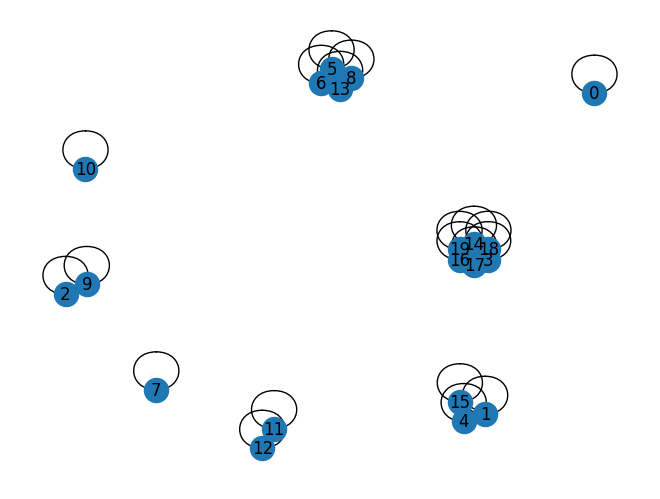

In [335]:
adj_fci = np.isclose(fci_similarity_scores, 1, atol=1e-2)
G_fci = nx.from_numpy_array(adj_fci)
nx.draw(G_fci, with_labels=True)

In [336]:
Us_fci[0]

array([[ 4.92605281e-01, -5.07263256e-01,  5.07290738e-01,
         4.92625753e-01],
       [-7.17414346e-01,  1.10799832e-06,  6.96646723e-01,
         4.62060682e-07],
       [-2.31494482e-06, -6.96682276e-01, -8.00088198e-07,
        -7.17379820e-01],
       [-4.92601962e-01, -5.07265014e-01, -5.07286360e-01,
         4.92631771e-01]])

In [337]:
Us_fci[2]

array([[-0.01036208,  0.01032343,  0.7070209 , -0.70704137],
       [ 0.70702852,  0.70703364,  0.01036607,  0.0103272 ],
       [-0.70703317,  0.7070291 , -0.01035908,  0.01032643],
       [-0.01036308, -0.0103302 ,  0.70704079,  0.70702137]])

In [338]:
print(Us_fci[4].T)

[[ 0.50727751 -0.70703986  0.49260183 -0.01037344]
 [ 0.49264287  0.70702198  0.50726338 -0.01033395]
 [-0.49261548 -0.01037774  0.50728508  0.70702485]
 [ 0.50724996  0.0103378  -0.4926349   0.7070371 ]]


### Comparison of best orbitals for linear H4

In [339]:
bonds = [1.089, 2.067, 2.556, 4.022]
hf_fci_overlaps = [0.9145832 , 0.45444372, 0.32026731, 0.23843144] # calculated elsewhere


### todo: run stuff for fixed abc for all of these

hf_xs_filenames = ("../outputs/H4_linear/20260512_161402_x_opt.txt",
                  "../outputs/H4_linear/20260512_155500_x_opt.txt",
                  "../outputs/H4_linear/20260512_152549_x_opt.txt",
                  "../outputs/H4_linear/20260512_163100_x_opt.txt")

fci_xs_filenames = ("../outputs/H4_linear/20260512_160540_x_opt.txt",
                  "../outputs/H4_linear/20260512_171031_x_opt.txt",
                  "../outputs/H4_linear/20260512_153557_x_opt.txt",
                  "../outputs/H4_linear/20260512_162443_x_opt.txt")

In [340]:
scores = []

for i, bond in enumerate(bonds):
    path_to_hf = hf_xs_filenames[i]
    path_to_fci = fci_xs_filenames[i]
    
    xs_fci_opt = np.loadtxt(path_to_fci, skiprows=1)
    xs_hf_opt = np.loadtxt(path_to_hf, skiprows=1)
    
    params_fci_opt = pd.read_csv(
        path_to_fci + "_results.txt",
    delimiter=" ")
    
    params_hf_opt = pd.read_csv(
        path_to_hf + "_results.txt",
    delimiter=" ")

    best_row_hf = np.argmin(params_hf_opt["C_hf"])
    best_row_fci = np.argmin(params_fci_opt["C_fci"])
    
    best_x_fci = xs_fci_opt[best_row_fci, :]
    best_x_hf = xs_hf_opt[best_row_hf, :]

    U_fci = x_to_U(best_x_fci[:-2], 4)
    U_hf = x_to_U(best_x_hf[:-2], 4)
    
    scores.append(basis_similarity(U_hf @ U_fci.T))

In [341]:
plt.rcParams.update({"font.size":13})

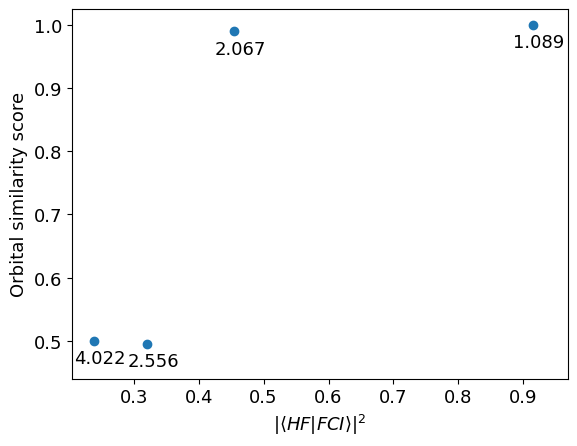

In [344]:
plt.figure()

for i, bond in enumerate(bonds):
    plt.text(hf_fci_overlaps[i] - 0.03, scores[i] - 0.035, str(bond))

plt.plot(hf_fci_overlaps, scores, "o")

ylim = plt.gca().get_ylim()
plt.ylim((ylim[0] - 0.03, ylim[1]))

xlim = plt.gca().get_xlim()
plt.xlim((xlim[0], xlim[1] + 0.02))

plt.xlabel(r"$|\langle HF | FCI \rangle|^2$")
plt.ylabel("Orbital similarity score")
plt.savefig("Orbital similarity H4.png", format="png", dpi=400, bbox_inches="tight")

#### How large or small can the basis similarity score be?

In [274]:
from scipy.stats import ortho_group

In [308]:
n_tries = 10000

data = np.zeros(n_tries)

dim = 5

for i in range(n_tries):
    U = ortho_group.rvs(dim)
    row_ind, col_ind = scipy.optimize.linear_sum_assignment(-abs(U)**2)
    data[i] = abs(U[row_ind, col_ind]**2).sum() / dim
    # data[i] = np.trace(abs(U))

In [309]:
np.min(data)

0.3255117912746339

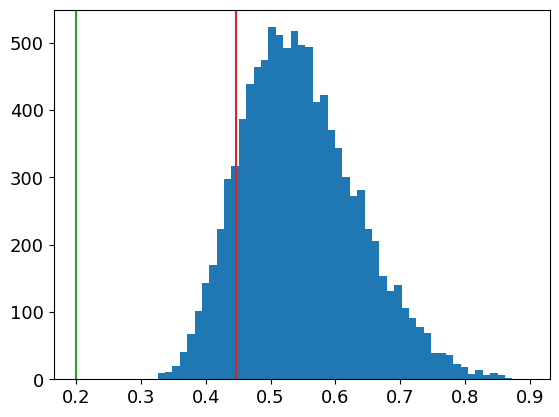

In [310]:
plt.hist(data, 50)
plt.axvline(1/dim**0.5, color="tab:red")
plt.axvline(1/dim, color="tab:green")
plt.show()